## Modeling the Effects of Temperature on Race Performance

This companion notebook is the source idea for the lighter weather section now used in the milestone report. The script-backed version of this workflow lives in `scripts/build_weather_analysis.py`, which builds the merged lap-weather dataset, fits the baseline regression, and saves the figure used by the final notebook.


In [18]:
# Install FastF1 if not already installed
# !pip install fastf1

import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('f1_cache', exist_ok=True)  # Add this line

fastf1.Cache.enable_cache('f1_cache')
# Enable local caching to avoid repeated API calls
fastf1.Cache.enable_cache('f1_cache')  # Creates a local folder called f1_cache

# Load 2024 Bahrain Grand Prix race session
session = fastf1.get_session(2024, 'Bahrain', 'R')
session.load()

print("Session loaded:", session.event['EventName'], session.date)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Session loaded: Bahrain Grand Prix 2024-03-02 15:00:00


In [19]:
# Preview weather data availability
weather = session.weather_data
print(f"Weather data shape: {weather.shape}")
print(f"Weather columns: {list(weather.columns)}")
weather[['Time', 'AirTemp', 'TrackTemp', 'Humidity', 'Rainfall']].head()

Weather data shape: (157, 8)
Weather columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']


,Time,AirTemp,TrackTemp,Humidity,Rainfall
0,0 days 00:00:14.093000,18.9,26.5,46.0,False
1,0 days 00:01:14.084000,18.9,26.5,46.0,False
2,0 days 00:02:14.093000,18.9,26.5,46.0,False
3,0 days 00:03:14.090000,18.9,26.2,45.0,False
4,0 days 00:04:14.091000,18.9,26.2,46.0,False


In [25]:
races = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China']
years = [2024, 2025]
all_data = []

for race in races:
    for year in years: 
        session = fastf1.get_session(year, race, 'R')
        session.load(telemetry=False, weather=True)
        
        laps = session.laps.copy()
        weather = session.weather_data.copy()
        
        laps['Race'] = race
        laps['Year'] = year
        
        laps = laps.sort_values('Time')
        weather = weather.sort_values('Time')
    
        laps_with_weather = pd.merge_asof(laps, weather, on='Time', direction='backward')
        
        all_data.append(laps_with_weather)

combined_df = pd.concat(all_data, ignore_index=True)

combined_df['LapTime_Seconds'] = combined_df['LapTime'].dt.total_seconds()

print(combined_df[['Race', 'LapNumber', 'LapTime_Seconds', 'AirTemp']].head())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for

      Race  LapNumber  LapTime_Seconds  AirTemp
0  Bahrain        1.0           97.284     18.3
1  Bahrain        1.0           98.271     18.3
2  Bahrain        1.0           99.228     18.3
3  Bahrain        1.0          100.053     18.3
4  Bahrain        1.0          100.620     18.3


                            OLS Regression Results                            
Dep. Variable:        LapTime_Seconds   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                nan
Time:                        19:04:53   Log-Likelihood:                -35739.
No. Observations:                9836   AIC:                         7.151e+04
Df Residuals:                    9821   BIC:                         7.162e+04
Df Model:                          14                                         
Covariance Type:                  HC2                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
C(Year)[2024]     

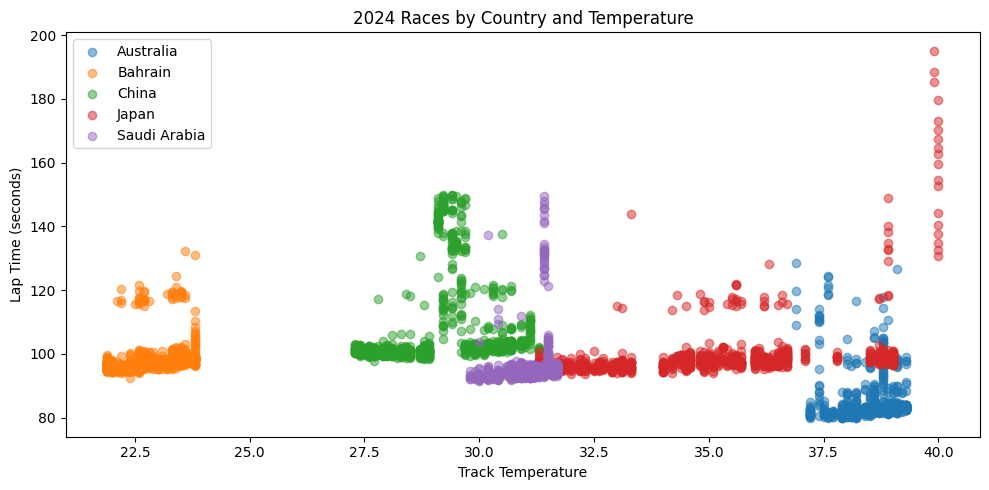

In [27]:
import statsmodels.formula.api as smf

# Multi-variate regression
reg = smf.ols(
    formula = '''LapTime_Seconds ~ 
                + C(Year)
                + C(Race)
                + C(Compound) - 1
                + TrackTemp
                + AirTemp
                + Pressure
                + Humidity
                + WindSpeed
                + WindDirection
                ''',
              data = combined_df
          ).fit(cov_type = 'HC2')

print(reg.summary())

# Temperature Scatter Plot
fig, ax = plt.subplots(figsize=(10, 5))

for race, group in combined_df[combined_df['Year'] == 2024].groupby('Race'):
    ax.scatter(group['TrackTemp'], group['LapTime_Seconds'], label=race, alpha=0.5)

ax.set_title('2024 Races by Country and Temperature')
ax.set_xlabel('Track Temperature')
ax.set_ylabel('Lap Time (seconds)')

ax.legend()
plt.tight_layout()
plt.show()

## Analysis

This notebook remains useful for iterating on the weather merge and regression framing, but the canonical report-facing outputs now come from `scripts/build_weather_analysis.py` and are consumed directly by the milestone notebook.
